# Informer Model for K8s Pod Count Prediction

In [1]:
%pip install pandas numpy scikit-learn tensorflow matplotlib seaborn keras-tuner -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 8.1 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import math
import warnings
from itertools import product
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import keras_tuner as kt

warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)

## Data Loading and Exploration

In [3]:
df = pd.read_csv('data.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'], format='mixed', dayfirst=False)

print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")
print(f"Services: {df['service_id'].unique()}")
df.head()

Dataset shape: (43200, 23)
Date range: 2025-11-01 00:00:00 to 2025-11-30 23:59:00
Services: ['Order']


,timestamp,service_id,current_pod_count,request_rate_rps,latency_p95_ms,latency_p99_ms,error_rate_percent,queue_length,pod_cpu_usage_percent_avg,pod_cpu_usage_percent_p95,...,hour_cos,day_sin,day_cos,mesh_inbound_rps,mesh_inbound_latency_p95,mesh_inbound_error_rate,degree_centrality,eigenvector_centrality,betweenness_centrality,closeness_centrality
0,2025-11-01 00:00:00,Order,2,73.30,85.09,111.69,0.0360,0.0,26.36,30.07,...,1.0,-0.9749,-0.2225,71.99,83.33,0.0371,0.8313,0.8591,0.6531,0.7367
1,2025-11-01 00:01:00,Order,2,75.69,93.87,131.05,0.0361,0.0,29.32,33.63,...,1.0,-0.9749,-0.2225,74.63,88.76,0.0341,0.7970,0.8745,0.6764,0.7216
2,2025-11-01 00:02:00,Order,2,79.28,91.01,123.72,0.0363,0.0,28.98,34.94,...,1.0,-0.9749,-0.2225,79.07,84.48,0.0343,0.8088,0.8933,0.6303,0.7102
3,2025-11-01 00:03:00,Order,2,81.81,84.87,103.11,0.0364,0.0,33.21,38.83,...,1.0,-0.9749,-0.2225,81.46,82.47,0.0397,0.7837,0.8883,0.6635,0.7434
4,2025-11-01 00:04:00,Order,2,81.72,80.07,99.22,0.0364,0.0,30.64,35.01,...,1.0,-0.9749,-0.2225,79.50,78.01,0.0378,0.8163,0.8750,0.6596,0.7066


In [4]:
SERVICE_NAME = 'Order'
df_service = df[df['service_id'] == SERVICE_NAME].copy()
df_service = df_service.sort_values('timestamp').reset_index(drop=True)

print(f"{SERVICE_NAME} service: {df_service.shape[0]} records")
print(f"Time range: {df_service['timestamp'].min()} to {df_service['timestamp'].max()}")
df_service.head(10)

Order service: 43200 records
Time range: 2025-11-01 00:00:00 to 2025-11-30 23:59:00


,timestamp,service_id,current_pod_count,request_rate_rps,latency_p95_ms,latency_p99_ms,error_rate_percent,queue_length,pod_cpu_usage_percent_avg,pod_cpu_usage_percent_p95,...,hour_cos,day_sin,day_cos,mesh_inbound_rps,mesh_inbound_latency_p95,mesh_inbound_error_rate,degree_centrality,eigenvector_centrality,betweenness_centrality,closeness_centrality
0,2025-11-01 00:00:00,Order,2,73.30,85.09,111.69,0.0360,0.0,26.36,30.07,...,1.0,-0.9749,-0.2225,71.99,83.33,0.0371,0.8313,0.8591,0.6531,0.7367
1,2025-11-01 00:01:00,Order,2,75.69,93.87,131.05,0.0361,0.0,29.32,33.63,...,1.0,-0.9749,-0.2225,74.63,88.76,0.0341,0.7970,0.8745,0.6764,0.7216
2,2025-11-01 00:02:00,Order,2,79.28,91.01,123.72,0.0363,0.0,28.98,34.94,...,1.0,-0.9749,-0.2225,79.07,84.48,0.0343,0.8088,0.8933,0.6303,0.7102
3,2025-11-01 00:03:00,Order,2,81.81,84.87,103.11,0.0364,0.0,33.21,38.83,...,1.0,-0.9749,-0.2225,81.46,82.47,0.0397,0.7837,0.8883,0.6635,0.7434
4,2025-11-01 00:04:00,Order,2,81.72,80.07,99.22,0.0364,0.0,30.64,35.01,...,1.0,-0.9749,-0.2225,79.50,78.01,0.0378,0.8163,0.8750,0.6596,0.7066
5,2025-11-01 00:05:00,Order,2,79.54,77.05,107.67,0.0363,0.0,33.51,41.81,...,1.0,-0.9749,-0.2225,81.78,73.01,0.0386,0.8339,0.8999,0.6665,0.7213
6,2025-11-01 00:06:00,Order,2,76.77,74.74,92.30,0.0361,0.0,31.61,38.97,...,1.0,-0.9749,-0.2225,74.91,70.94,0.0337,0.7788,0.8963,0.6463,0.7154
7,2025-11-01 00:07:00,Order,2,73.14,68.89,83.51,0.0358,0.0,31.90,37.61,...,1.0,-0.9749,-0.2225,73.55,66.46,0.0359,0.8154,0.8885,0.6172,0.7499
8,2025-11-01 00:08:00,Order,2,67.87,65.17,80.54,0.0355,0.0,30.97,36.11,...,1.0,-0.9749,-0.2225,68.22,62.69,0.0360,0.8420,0.8913,0.6731,0.7258
9,2025-11-01 00:09:00,Order,2,63.85,65.07,83.15,0.0353,0.0,27.89,34.60,...,1.0,-0.9749,-0.2225,63.34,61.92,0.0335,0.8200,0.8779,0.6477,0.7490


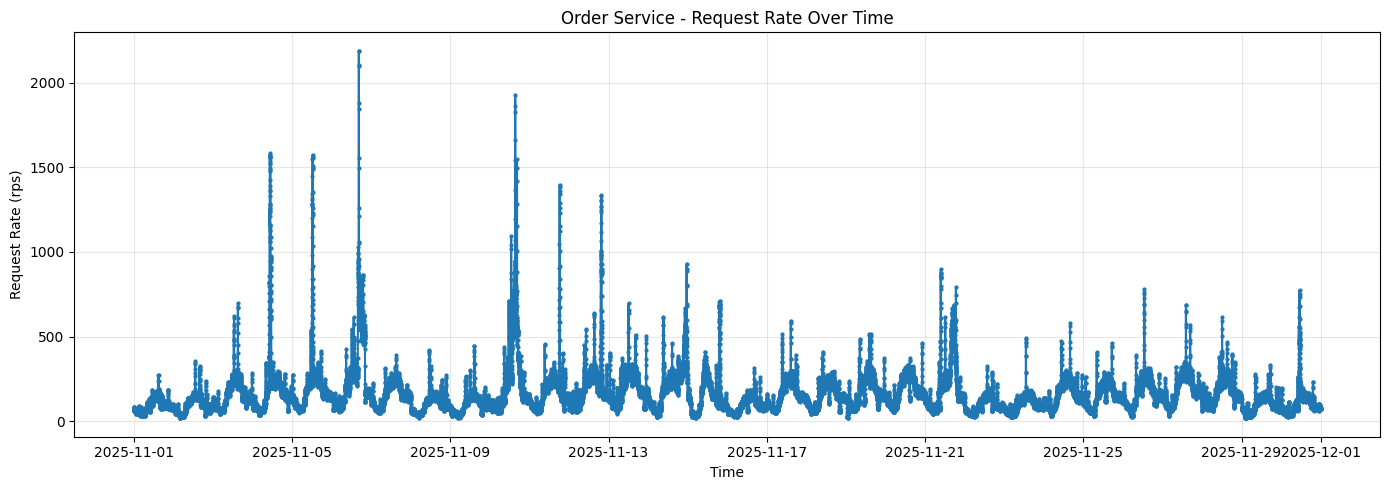

count    43200.000000
mean       160.078258
std        123.435016
min         17.590000
25%         85.330000
50%        136.545000
75%        204.012500
max       2187.940000
Name: request_rate_rps, dtype: float64


In [5]:
plt.figure(figsize=(14, 5))
plt.plot(df_service['timestamp'], df_service['request_rate_rps'], marker='o', markersize=2)
plt.title(f'{SERVICE_NAME} Service - Request Rate Over Time')
plt.xlabel('Time')
plt.ylabel('Request Rate (rps)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(df_service['request_rate_rps'].describe())

## Data Diagnostics

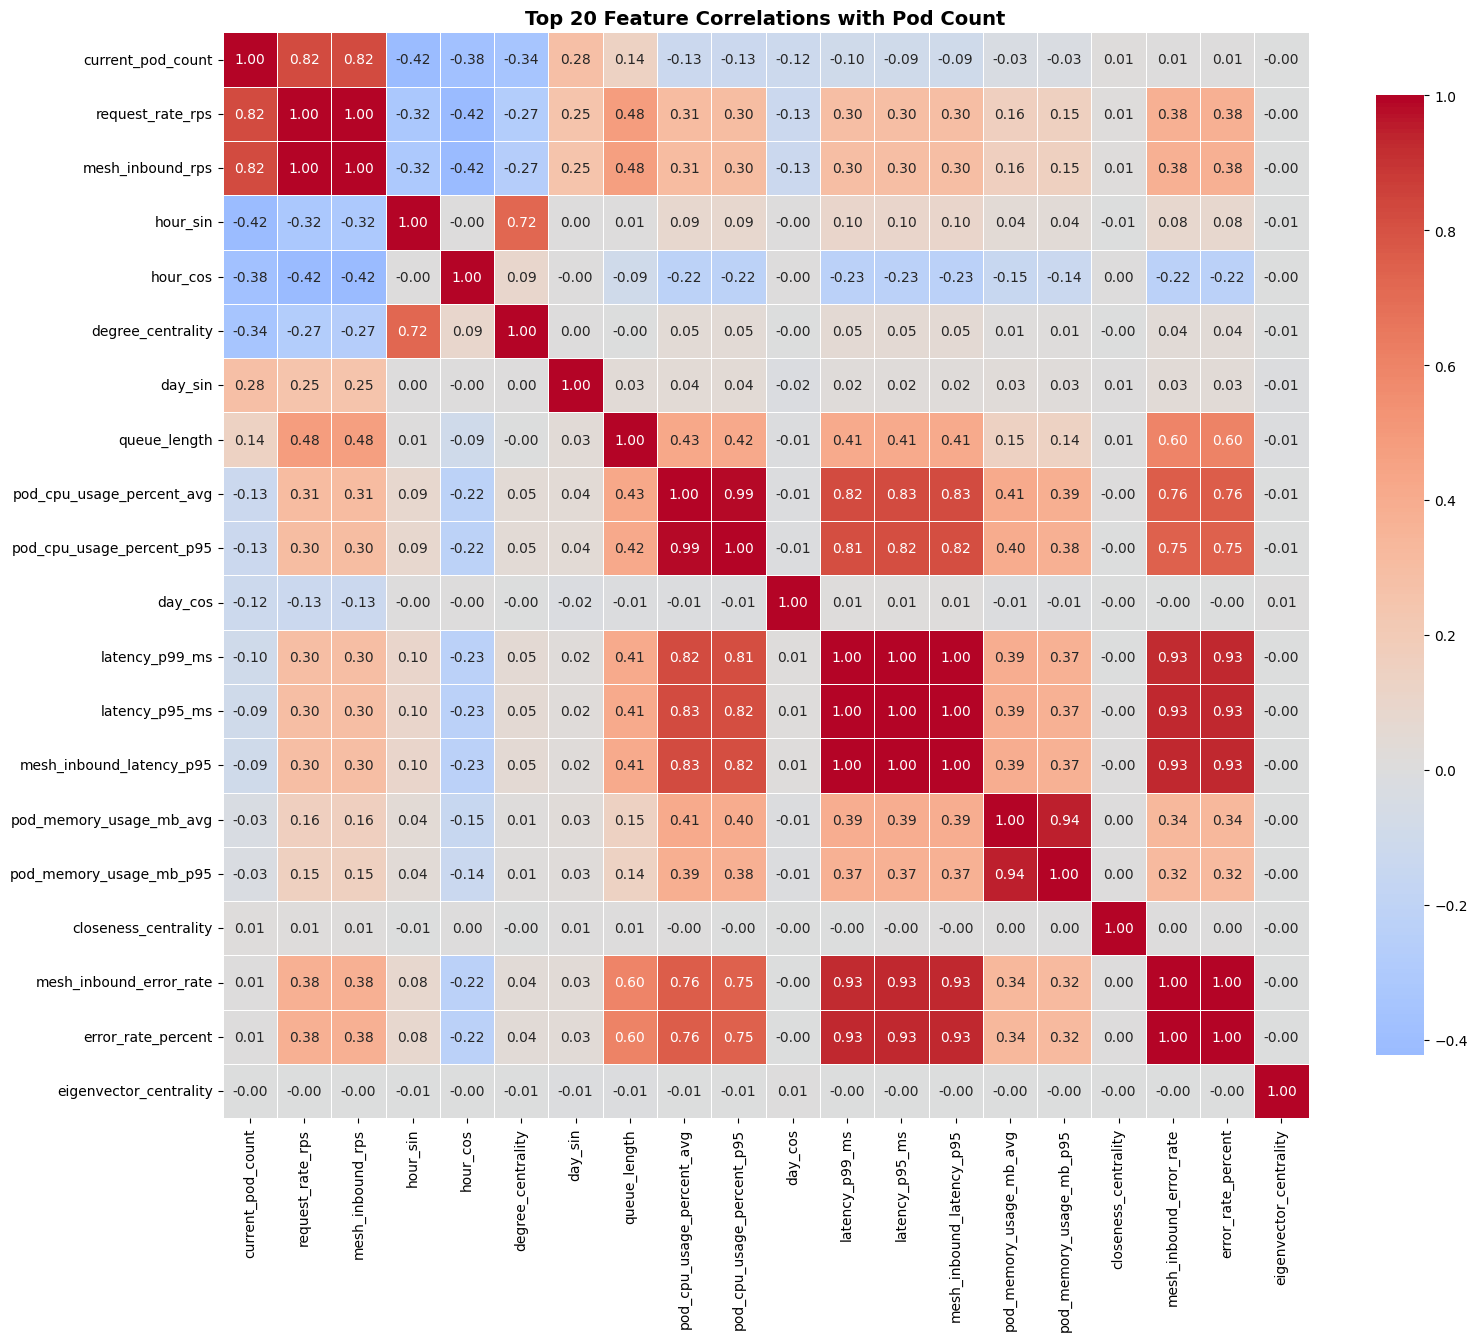

Top correlations with current_pod_count:
  + request_rate_rps                        : 0.8179
  + mesh_inbound_rps                        : 0.8176
  - hour_sin                                : 0.4158
  - hour_cos                                : 0.3767
  - degree_centrality                       : 0.3405
  + day_sin                                 : 0.2838
  + queue_length                            : 0.1395
  - pod_cpu_usage_percent_avg               : 0.1273
  - pod_cpu_usage_percent_p95               : 0.1254
  - day_cos                                 : 0.1217
  - latency_p99_ms                          : 0.0953
  - latency_p95_ms                          : 0.0948
  - mesh_inbound_latency_p95                : 0.0945
  - pod_memory_usage_mb_avg                 : 0.0304
  - pod_memory_usage_mb_p95                 : 0.0277


In [6]:
numeric_cols = df_service.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [col for col in numeric_cols if col not in ['timestamp', 'service_id']]

corr_matrix = df_service[numeric_cols].corr()

plt.figure(figsize=(16, 14))
top_features = corr_matrix['current_pod_count'].abs().sort_values(ascending=False).head(20).index
sns.heatmap(df_service[top_features].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Top 20 Feature Correlations with Pod Count', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

print("Top correlations with current_pod_count:")
top_corr = corr_matrix['current_pod_count'].abs().sort_values(ascending=False).head(16)
for feature, corr_value in top_corr.items():
    if feature != 'current_pod_count':
        sign = '+' if corr_matrix['current_pod_count'][feature] > 0 else '-'
        print(f"  {sign} {feature:40s}: {abs(corr_value):.4f}")

In [7]:
missing = df_service.isnull().sum()
print(f"Missing values: {missing.sum()}")
if missing.sum() > 0:
    print(missing[missing > 0])

constant_features = [col for col in numeric_cols if df_service[col].nunique() == 1]
print(f"Constant features: {constant_features if constant_features else 'None'}")

print(f"Dataset size: {len(df_service):,} samples")
print(f"Time span: {(df_service['timestamp'].max() - df_service['timestamp'].min()).days} days")

Missing values: 0
Constant features: None
Dataset size: 43,200 samples
Time span: 29 days


## Configuration

In [8]:
# Device setup
if tf.config.list_physical_devices('GPU'):
    DEVICE_TYPE = 'GPU'
    strategy = tf.distribute.MirroredStrategy()
else:
    DEVICE_TYPE = 'CPU'
    strategy = tf.distribute.OneDeviceStrategy(device='/cpu:0')
print(f'Running on {DEVICE_TYPE}')

# =============================================================================
# OPTIMIZED TRAINING PARAMETERS (Fixed overfitting issues)
# =============================================================================

# Time windows - SHORTENED for faster autoscaling response
LOOKBACK = 12  # Was 20-30, now 12 minutes of history (K8s reacts in seconds)
PREDICTION_HORIZON = 1  # Was 5, now predict 1 step ahead (immediate response)

# Training parameters
EPOCHS = 300
BATCH_SIZE = 32  # Was 128 (30% of data!), now 32 for better regularization
LEARNING_RATE = 0.001  # Slightly higher for simpler model
GRADIENT_CLIP_NORM = 1.0
EARLY_STOPPING_PATIENCE = 30
REDUCE_LR_PATIENCE = 15

# Loss configuration for single output (pod count prediction)
USE_ASYMMETRIC_LOSS = True
UNDER_PRED_PENALTY = 2.0  # Penalize under-prediction (avoid SLA violations)
OVER_PRED_PENALTY = 1.0   # Over-prediction wastes resources but safer

# =============================================================================
# SIMPLIFIED MODEL ARCHITECTURE (Reduced from 2.1M to ~200K params)
# =============================================================================
# Your data has strong direct correlations (request_rate = 0.82 with pod count)
# Complex temporal patterns are NOT the issue - simpler model will generalize better

MODEL_CONFIG = {
    'd_model': 64,       # Was 128
    'num_heads': 4,      # Was 16 (overkill for this data)
    'num_layers': 2,     # Was 5 (massive overfitting risk)
    'dff': 128,          # Was 256
    'dropout_rate': 0.35,  # Was 0.1 (way too low!)
    'activation': 'gelu'
}

# Increased regularization
L2_REGULARIZATION = 1e-3  # Was 1e-4 (10x increase)

HYPERPARAMETER_TUNING = False
USE_OPTIMIZED_CONFIG = True

print(f"=" * 60)
print("OPTIMIZED CONFIGURATION (Anti-Overfitting)")
print(f"=" * 60)
print(f"Lookback: {LOOKBACK} (was 20-30), Horizon: {PREDICTION_HORIZON} (was 5)")
print(f"Batch size: {BATCH_SIZE} (was 128), L2: {L2_REGULARIZATION} (was 1e-4)")
print(f"Model: d_model={MODEL_CONFIG['d_model']}, layers={MODEL_CONFIG['num_layers']}, "
      f"heads={MODEL_CONFIG['num_heads']}, dropout={MODEL_CONFIG['dropout_rate']}")
print(f"Target: future_current_pod_count (single output)")

Running on GPU
OPTIMIZED CONFIGURATION (Anti-Overfitting)
Lookback: 12 (was 20-30), Horizon: 1 (was 5)
Batch size: 32 (was 128), L2: 0.001 (was 1e-4)
Model: d_model=64, layers=2, heads=4, dropout=0.35
Target: future_current_pod_count (single output)


## Data Preprocessing

In [9]:
# Create future pod count target (THIS IS THE CORRECT TARGET FOR AUTOSCALING)
df_service['future_current_pod_count'] = df_service['current_pod_count'].shift(-PREDICTION_HORIZON)

df_service = df_service[:-PREDICTION_HORIZON].copy()
print(f"Dataset shape after creating target: {df_service.shape}")

Dataset shape after creating target: (43199, 24)


In [10]:
# Lag features
for lag in [1, 2, 3, 5, 10]:
    df_service[f'pod_count_lag_{lag}'] = df_service['current_pod_count'].shift(lag)
    df_service[f'request_rate_lag_{lag}'] = df_service['request_rate_rps'].shift(lag)
    df_service[f'cpu_lag_{lag}'] = df_service['pod_cpu_usage_percent_avg'].shift(lag)

# Rolling statistics
for window in [5, 10, 20]:
    df_service[f'pod_count_rolling_mean_{window}'] = df_service['current_pod_count'].rolling(window=window, min_periods=1).mean()
    df_service[f'pod_count_rolling_std_{window}'] = df_service['current_pod_count'].rolling(window=window, min_periods=1).std()
    df_service[f'request_rate_rolling_mean_{window}'] = df_service['request_rate_rps'].rolling(window=window, min_periods=1).mean()
    df_service[f'cpu_rolling_mean_{window}'] = df_service['pod_cpu_usage_percent_avg'].rolling(window=window, min_periods=1).mean()

# Rate of change features
df_service['pod_count_diff'] = df_service['current_pod_count'].diff()
df_service['request_rate_diff'] = df_service['request_rate_rps'].diff()
df_service['cpu_diff'] = df_service['pod_cpu_usage_percent_avg'].diff()

df_service = df_service.fillna(method='bfill').fillna(method='ffill')
print(f"Basic features created. Shape: {df_service.shape}")

Basic features created. Shape: (43199, 54)


## Advanced Feature Engineering

In [11]:
# Exponential Moving Averages
df_service['request_rate_ema_5'] = df_service['request_rate_rps'].ewm(span=5, adjust=False).mean()
df_service['request_rate_ema_15'] = df_service['request_rate_rps'].ewm(span=15, adjust=False).mean()
df_service['cpu_ema_5'] = df_service['pod_cpu_usage_percent_avg'].ewm(span=5, adjust=False).mean()
df_service['cpu_ema_15'] = df_service['pod_cpu_usage_percent_avg'].ewm(span=15, adjust=False).mean()
df_service['latency_ema_5'] = df_service['latency_p95_ms'].ewm(span=5, adjust=False).mean()

# Interaction features
df_service['load_factor'] = df_service['request_rate_rps'] * df_service['pod_cpu_usage_percent_avg']
df_service['memory_pressure'] = df_service['pod_memory_usage_mb_avg'] / (df_service['current_pod_count'] + 1)
df_service['requests_per_pod'] = df_service['request_rate_rps'] / (df_service['current_pod_count'] + 1)
df_service['cpu_per_request'] = df_service['pod_cpu_usage_percent_avg'] / (df_service['request_rate_rps'] + 1)
df_service['error_latency_product'] = df_service['error_rate_percent'] * df_service['latency_p95_ms']

# Ratios
df_service['cpu_to_memory_ratio'] = df_service['pod_cpu_usage_percent_avg'] / (df_service['pod_memory_usage_mb_avg'] + 1)
df_service['p95_to_avg_cpu_ratio'] = df_service['pod_cpu_usage_percent_p95'] / (df_service['pod_cpu_usage_percent_avg'] + 1)
df_service['inbound_to_outbound_ratio'] = df_service['mesh_inbound_rps'] / (df_service['request_rate_rps'] + 1)

# Acceleration
df_service['request_rate_acceleration'] = df_service['request_rate_diff'].diff()
df_service['cpu_acceleration'] = df_service['cpu_diff'].diff()

# Rolling min/max
for window in [5, 10]:
    df_service[f'request_rate_rolling_max_{window}'] = df_service['request_rate_rps'].rolling(window=window, min_periods=1).max()
    df_service[f'cpu_rolling_max_{window}'] = df_service['pod_cpu_usage_percent_avg'].rolling(window=window, min_periods=1).max()
    df_service[f'latency_rolling_max_{window}'] = df_service['latency_p95_ms'].rolling(window=window, min_periods=1).max()

# Trend indicators
df_service['request_rate_trend_5'] = df_service['request_rate_rps'] - df_service['request_rate_ema_5']
df_service['cpu_trend_5'] = df_service['pod_cpu_usage_percent_avg'] - df_service['cpu_ema_5']

# Volatility
df_service['request_rate_volatility'] = df_service['request_rate_rps'].rolling(window=10, min_periods=1).std() / (df_service['request_rate_ema_5'] + 1)
df_service['cpu_volatility'] = df_service['pod_cpu_usage_percent_avg'].rolling(window=10, min_periods=1).std() / (df_service['cpu_ema_5'] + 1)

# Cumulative sum
df_service['request_rate_cumsum_10'] = df_service['request_rate_diff'].rolling(window=10, min_periods=1).sum()
df_service['cpu_cumsum_10'] = df_service['cpu_diff'].rolling(window=10, min_periods=1).sum()

# Network centrality interactions
df_service['centrality_load'] = df_service['degree_centrality'] * df_service['mesh_inbound_rps']
df_service['betweenness_requests'] = df_service['betweenness_centrality'] * df_service['request_rate_rps']

df_service = df_service.fillna(method='bfill').fillna(method='ffill').fillna(0)
print(f"Advanced features created. Shape: {df_service.shape}")

Advanced features created. Shape: (43199, 83)


In [12]:
base_feature_cols = [
    'current_pod_count', 'request_rate_rps', 'latency_p95_ms', 'error_rate_percent',
    'queue_length', 'pod_cpu_usage_percent_avg', 'pod_cpu_usage_percent_p95',
    'pod_memory_usage_mb_avg', 'pod_memory_usage_mb_p95', 'mesh_inbound_rps',
    'mesh_inbound_latency_p95', 'mesh_inbound_error_rate', 'degree_centrality',
    'eigenvector_centrality', 'betweenness_centrality', 'closeness_centrality',
    'hour_sin', 'hour_cos', 'day_sin', 'day_cos'
]

engineered_patterns = ['lag_', 'rolling_', 'diff', 'ema_', 'factor', 'pressure',
                       'per_pod', 'per_request', 'product', 'ratio',
                       'acceleration', 'trend_', 'volatility', 'cumsum',
                       'centrality_load', 'betweenness_requests']

engineered_cols = [col for col in df_service.columns
                   if any(pattern in col for pattern in engineered_patterns)]

feature_cols = base_feature_cols + engineered_cols

# Single target for autoscaling: future pod count
target_cols = ['future_current_pod_count']

print(f"Features: {len(feature_cols)} (Base: {len(base_feature_cols)}, Engineered: {len(engineered_cols)})")
print(f"Target: {target_cols[0]} (single output for autoscaling)")

Features: 79 (Base: 20, Engineered: 59)
Target: future_current_pod_count (single output for autoscaling)


In [13]:
# Single target: future pod count (correct for autoscaling)
target_cols = ['future_current_pod_count']

# Handle missing values
missing_counts = df_service[feature_cols + target_cols].isnull().sum()
if missing_counts.sum() > 0:
    df_service[feature_cols] = df_service[feature_cols].fillna(method='ffill').fillna(method='bfill').fillna(0)
    df_service[target_cols] = df_service[target_cols].fillna(method='ffill').fillna(method='bfill').fillna(0)

print(f"Dataset ready: {df_service.shape}, Features: {len(feature_cols)}, Target: {target_cols[0]}")

Dataset ready: (43199, 83), Features: 79, Target: future_current_pod_count


## Train/Validation/Test Split

In [14]:
train_size = int(0.70 * len(df_service))
val_size = int(0.15 * len(df_service))

train_df = df_service[:train_size].copy()
val_df = df_service[train_size:train_size + val_size].copy()
test_df = df_service[train_size + val_size:].copy()

print(f"Train: {len(train_df)} ({len(train_df)/len(df_service)*100:.1f}%)")
print(f"Validation: {len(val_df)} ({len(val_df)/len(df_service)*100:.1f}%)")
print(f"Test: {len(test_df)} ({len(test_df)/len(df_service)*100:.1f}%)")

Train: 30239 (70.0%)
Validation: 6479 (15.0%)
Test: 6481 (15.0%)


In [15]:
scaler_X = StandardScaler()
scaler_y = StandardScaler()

scaler_X.fit(train_df[feature_cols])
scaler_y.fit(train_df[target_cols])

train_X_scaled = scaler_X.transform(train_df[feature_cols])
train_y_scaled = scaler_y.transform(train_df[target_cols])

val_X_scaled = scaler_X.transform(val_df[feature_cols])
val_y_scaled = scaler_y.transform(val_df[target_cols])

test_X_scaled = scaler_X.transform(test_df[feature_cols])
test_y_scaled = scaler_y.transform(test_df[target_cols])

print(f"Train X: {train_X_scaled.shape}, Train y: {train_y_scaled.shape}")

Train X: (30239, 79), Train y: (30239, 1)


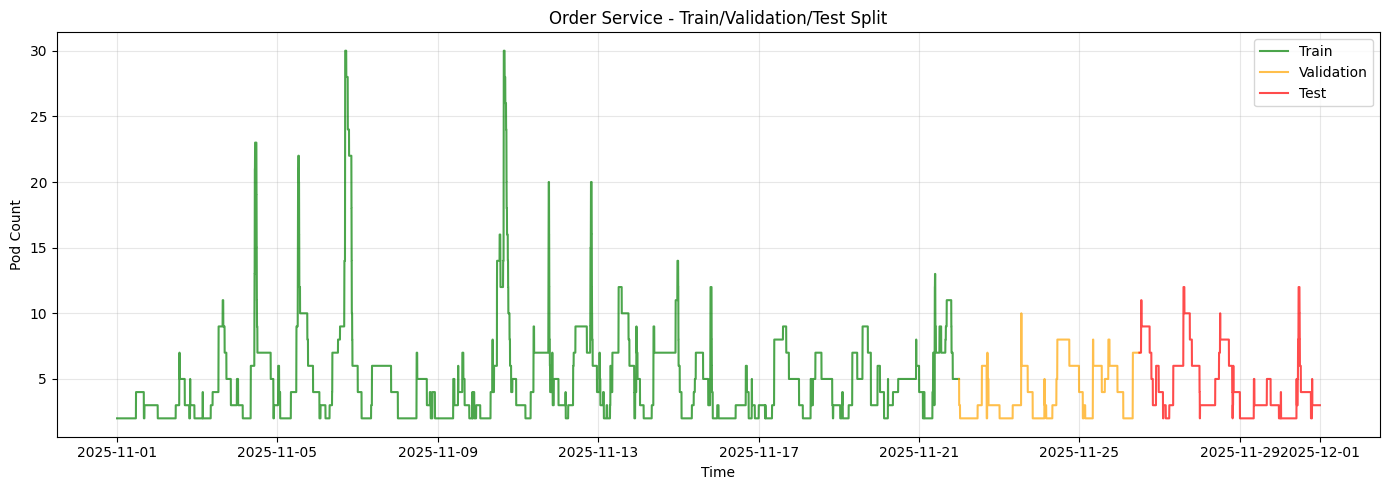

In [16]:
plt.figure(figsize=(14, 5))
plt.plot(train_df['timestamp'], train_df['current_pod_count'], label='Train', color='green', alpha=0.7)
plt.plot(val_df['timestamp'], val_df['current_pod_count'], label='Validation', color='orange', alpha=0.7)
plt.plot(test_df['timestamp'], test_df['current_pod_count'], label='Test', color='red', alpha=0.7)
plt.title(f'{SERVICE_NAME} Service - Train/Validation/Test Split')
plt.xlabel('Time')
plt.ylabel('Pod Count')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Sequence Generation

In [17]:
def create_sequences(X, y, lookback=10):
    """Create sequences for time-series prediction with multi-output targets."""
    X_seq, y_seq = [], []
    for i in range(len(X) - lookback):
        X_seq.append(X[i:i + lookback])
        y_seq.append(y[i + lookback])
    return np.array(X_seq), np.array(y_seq)

print(f"Lookback: {LOOKBACK} timesteps, Device: {DEVICE_TYPE}")

Lookback: 12 timesteps, Device: GPU


In [18]:
X_train_seq, y_train_seq = create_sequences(train_X_scaled, train_y_scaled, lookback=LOOKBACK)
X_val_seq, y_val_seq = create_sequences(val_X_scaled, val_y_scaled, lookback=LOOKBACK)
X_test_seq, y_test_seq = create_sequences(test_X_scaled, test_y_scaled, lookback=LOOKBACK)

print(f"Train: {X_train_seq.shape}, Val: {X_val_seq.shape}, Test: {X_test_seq.shape}")

Train: (30227, 12, 79), Val: (6467, 12, 79), Test: (6469, 12, 79)


## Informer Model Definition

In [19]:
def positional_encoding(length, depth):
    """Generate positional encoding for transformer."""
    depth = int(depth / 2)
    positions = np.arange(length)[:, np.newaxis]
    depths = np.arange(depth)[np.newaxis, :] / depth
    angle_rates = 1 / (10000 ** depths)
    angle_rads = positions * angle_rates
    pos_encoding = np.concatenate([np.sin(angle_rads), np.cos(angle_rads)], axis=-1)
    return tf.cast(pos_encoding, dtype=tf.float32)


class PositionalEmbedding(layers.Layer):
    """Positional embedding layer."""
    def __init__(self, sequence_length, d_model, **kwargs):
        super().__init__(**kwargs)
        self.d_model = d_model
        self.sequence_length = sequence_length
        self.pos_encoding = positional_encoding(length=sequence_length, depth=d_model)

    def call(self, x):
        length = tf.shape(x)[1]
        return x + self.pos_encoding[tf.newaxis, :length, :]

    def get_config(self):
        config = super().get_config()
        config.update({"sequence_length": self.sequence_length, "d_model": self.d_model})
        return config

In [20]:
def asymmetric_mse_loss(under_pred_penalty=2.0, over_pred_penalty=1.0):
    """
    Simple asymmetric MSE loss for single-output pod count prediction.
    No multi-target weighting - avoids conflicting gradients.

    Under-prediction (actual > predicted): SLA risk - penalize more
    Over-prediction (actual < predicted): Cost waste - penalize less
    """
    def loss(y_true, y_pred):
        error = y_true - y_pred
        loss = tf.where(error > 0,
                        under_pred_penalty * tf.square(error),
                        over_pred_penalty * tf.square(error))
        return tf.reduce_mean(loss)
    return loss

print("Loss: Simple asymmetric MSE (no multi-target conflicts)")

Loss: Simple asymmetric MSE (no multi-target conflicts)


In [21]:
class MultiHeadSelfAttention(layers.Layer):
    def __init__(self, d_model, num_heads, dropout_rate=0.0, **kwargs):
        super().__init__(**kwargs)
        self.num_heads = num_heads
        self.d_model = d_model
        assert d_model % num_heads == 0
        self.depth = d_model // num_heads
        self.wq = layers.Dense(d_model, kernel_regularizer=keras.regularizers.l2(L2_REGULARIZATION))
        self.wk = layers.Dense(d_model, kernel_regularizer=keras.regularizers.l2(L2_REGULARIZATION))
        self.wv = layers.Dense(d_model, kernel_regularizer=keras.regularizers.l2(L2_REGULARIZATION))
        self.dense = layers.Dense(d_model, kernel_regularizer=keras.regularizers.l2(L2_REGULARIZATION))
        self.dropout = layers.Dropout(dropout_rate)

    def split_heads(self, x, batch_size):
        x = tf.reshape(x, (batch_size, -1, self.num_heads, self.depth))
        return tf.transpose(x, perm=[0, 2, 1, 3])

    def call(self, v, k, q, training=False, mask=None):
        batch_size = tf.shape(q)[0]
        q, k, v = self.wq(q), self.wk(k), self.wv(v)
        q = self.split_heads(q, batch_size)
        k = self.split_heads(k, batch_size)
        v = self.split_heads(v, batch_size)

        matmul_qk = tf.matmul(q, k, transpose_b=True)
        dk = tf.cast(tf.shape(k)[-1], tf.float32)
        scaled_attention_logits = matmul_qk / tf.math.sqrt(dk)

        if mask is not None:
            scaled_attention_logits += (mask * -1e9)

        attention_weights = tf.nn.softmax(scaled_attention_logits, axis=-1)
        output = tf.matmul(attention_weights, v)
        output = tf.transpose(output, perm=[0, 2, 1, 3])
        concat_attention = tf.reshape(output, (batch_size, -1, self.d_model))
        return self.dropout(self.dense(concat_attention), training=training), attention_weights

    def get_config(self):
        config = super().get_config()
        config.update({"num_heads": self.num_heads, "d_model": self.d_model})
        return config


class OptimizedTransformerBlock(layers.Layer):
    def __init__(self, d_model, num_heads, dff, dropout_rate=0.35, activation='gelu', **kwargs):
        super().__init__(**kwargs)
        self.d_model, self.num_heads, self.dff = d_model, num_heads, dff
        self.dropout_rate, self.activation = dropout_rate, activation

        self.mha = MultiHeadSelfAttention(d_model, num_heads, dropout_rate=dropout_rate)
        self.ffn_block = keras.Sequential([
            layers.Dense(dff, activation=activation, kernel_regularizer=keras.regularizers.l2(L2_REGULARIZATION)),
            layers.Dropout(dropout_rate),  # Added dropout in FFN
            layers.Dense(d_model, kernel_regularizer=keras.regularizers.l2(L2_REGULARIZATION))
        ])
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(dropout_rate)
        self.dropout2 = layers.Dropout(dropout_rate)

    def call(self, x, training=False, mask=None):
        attn_output, _ = self.mha(x, x, x, training=training, mask=mask)
        out1 = self.layernorm1(x + self.dropout1(attn_output, training=training))
        ffn_output = self.ffn_block(out1)
        return self.layernorm2(out1 + self.dropout2(ffn_output, training=training))

    def get_config(self):
        config = super().get_config()
        config.update({"d_model": self.d_model, "num_heads": self.num_heads, "dff": self.dff,
                       "dropout_rate": self.dropout_rate, "activation": self.activation})
        return config


def build_informer_model(seq_length, n_features, n_outputs=1, d_model=64, num_heads=4,
                         num_layers=2, dff=128, dropout_rate=0.35):
    """
    Build SIMPLIFIED Informer model for pod count forecasting.
    Optimized for 43K samples - reduced parameters to prevent overfitting.
    """
    inputs = layers.Input(shape=(seq_length, n_features), name='input')

    # Input projection with L2 regularization
    x = layers.Dense(d_model, kernel_regularizer=keras.regularizers.l2(L2_REGULARIZATION),
                     name='input_projection')(inputs)
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    x = PositionalEmbedding(seq_length, d_model)(x)
    x = layers.Dropout(dropout_rate)(x)

    # Reduced transformer layers (2 instead of 5)
    for i in range(num_layers):
        x = OptimizedTransformerBlock(d_model, num_heads, dff, dropout_rate)(x, training=True)

    # Simplified head - just use last timestep (more direct for single-step prediction)
    last_step = x[:, -1, :]

    # Smaller dense layers with stronger regularization
    dense1 = layers.Dense(64, activation='relu',
                          kernel_regularizer=keras.regularizers.l2(L2_REGULARIZATION))(last_step)
    dense1 = layers.Dropout(dropout_rate)(dense1)
    dense1 = layers.LayerNormalization(epsilon=1e-6)(dense1)

    dense2 = layers.Dense(32, activation='relu',
                          kernel_regularizer=keras.regularizers.l2(L2_REGULARIZATION))(dense1)
    dense2 = layers.Dropout(dropout_rate)(dense2)

    # Single output: future pod count
    outputs = layers.Dense(n_outputs, name='output_pod_count')(dense2)

    return keras.Model(inputs=inputs, outputs=outputs, name='Informer_PodCount_Light')

In [22]:
if HYPERPARAMETER_TUNING:
    def build_model_for_tuning(hp):
        with strategy.scope():
            model = build_informer_model(
                seq_length=LOOKBACK, n_features=len(feature_cols), n_outputs=1,
                d_model=hp.Choice('d_model', [32, 64]),  # Smaller range
                num_heads=hp.Choice('num_heads', [2, 4]),  # Fewer heads
                num_layers=hp.Choice('num_layers', [1, 2]),  # Fewer layers
                dff=hp.Choice('dff', [64, 128]),  # Smaller FFN
                dropout_rate=hp.Float('dropout_rate', 0.25, 0.45, step=0.05)  # Higher dropout
            )
            lr = hp.Float('learning_rate', 5e-4, 5e-3, sampling='log')
            model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr), loss='mse', metrics=['mae'])
        return model

    tuner = kt.BayesianOptimization(build_model_for_tuning, objective='val_loss', max_trials=15,
                                     directory='hyperparam_tuning', project_name='informer_k8s_light')
    tuner.search(X_train_seq, y_train_seq, validation_data=(X_val_seq, y_val_seq),
                 epochs=50, batch_size=BATCH_SIZE,
                 callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)])
    best_hps = tuner.get_best_hyperparameters(1)[0]
    print(f"Best params: d_model={best_hps.get('d_model')}, heads={best_hps.get('num_heads')}, "
          f"layers={best_hps.get('num_layers')}, dff={best_hps.get('dff')}, "
          f"dropout={best_hps.get('dropout_rate'):.2f}, lr={best_hps.get('learning_rate'):.6f}")
    with strategy.scope():
        model = tuner.hypermodel.build(best_hps)
else:
    config = MODEL_CONFIG
    with strategy.scope():
        model = build_informer_model(
            seq_length=LOOKBACK, n_features=len(feature_cols), n_outputs=1,
            d_model=config['d_model'], num_heads=config['num_heads'],
            num_layers=config['num_layers'], dff=config['dff'], dropout_rate=config['dropout_rate']
        )
        model.compile(optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
                      loss='mse', metrics=['mae', 'mse'])

print(f"\nModel: {model.name}")
print(f"Parameters: {model.count_params():,} (was ~2.1M, now much smaller)")
model.summary()


Model: Informer_PodCount_Light
Parameters: 78,593 (was ~2.1M, now much smaller)


Model: "Informer_PodCount_Light"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 12, 79)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ input_projection (Dense)        │ (None, 12, 64)         │         5,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ (None, 12, 64)         │           128 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ positional_embedding            │ (None, 12, 64)         │             0 │
│ (PositionalEmbedding)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ optimized_transformer_block     │ (None, 12, 64)         │        33,472 │
│ (OptimizedTransformerBlock)     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ optimized_transformer_block_1   │ (None, 12, 64)         │        33,472 │
│ (OptimizedTransformerBlock)     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ get_item (GetItem)              │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_5           │ (None, 64)             │           128 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_pod_count (Dense)        │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 78,593 (307.00 KB)

 Trainable params: 78,593 (307.00 KB)

 Non-trainable params: 0 (0.00 B)

## Model Training

In [23]:
if USE_ASYMMETRIC_LOSS:
    loss_fn = asymmetric_mse_loss(UNDER_PRED_PENALTY, OVER_PRED_PENALTY)
else:
    loss_fn = 'mse'

with strategy.scope():
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE, clipnorm=GRADIENT_CLIP_NORM),
        loss=loss_fn,
        metrics=['mae', 'mse']
    )
print(f"Compiled with {'Asymmetric MSE (under-pred penalty={UNDER_PRED_PENALTY})' if USE_ASYMMETRIC_LOSS else 'MSE'}")

Compiled with Asymmetric MSE (under-pred penalty={UNDER_PRED_PENALTY})


In [24]:
# Simpler learning rate schedule for smaller model
def cosine_annealing_schedule(epoch, lr):
    max_epochs, min_lr, max_lr = EPOCHS, 1e-6, LEARNING_RATE
    if epoch < 5:  # Shorter warmup for simpler model
        return max_lr * (epoch + 1) / 5
    progress = (epoch - 5) / (max_epochs - 5)
    return min_lr + (max_lr - min_lr) * 0.5 * (1 + math.cos(math.pi * progress))

callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=EARLY_STOPPING_PATIENCE,
                                   restore_best_weights=True, min_delta=1e-5),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=REDUCE_LR_PATIENCE,
                                       min_lr=1e-6, min_delta=1e-5),
    keras.callbacks.LearningRateScheduler(cosine_annealing_schedule, verbose=0),
    keras.callbacks.ModelCheckpoint('models/informer_best.keras', monitor='val_loss',
                                     save_best_only=True, save_weights_only=False),
    keras.callbacks.CSVLogger('training_history.csv', append=False)
]

In [25]:
print(f"Training: {len(X_train_seq):,} samples, {EPOCHS} epochs, batch={BATCH_SIZE}")
print(f"Regularization: L2={L2_REGULARIZATION}, dropout={MODEL_CONFIG['dropout_rate']}")

start_time = time.time()
with strategy.scope():
    history = model.fit(
        X_train_seq, y_train_seq,
        validation_data=(X_val_seq, y_val_seq),
        epochs=EPOCHS, batch_size=BATCH_SIZE,
        callbacks=callbacks, verbose=1
    )
training_time = time.time() - start_time
print(f"\nTraining completed in {training_time/60:.2f} minutes")

Training: 30,227 samples, 300 epochs, batch=32
Regularization: L2=0.001, dropout=0.35
Epoch 1/300
945/945 ━━━━━━━━━━━━━━━━━━━━ 47s 30ms/step - loss: 3.0590 - mae: 0.8013 - mse: 1.2956 - val_loss: 1.0300 - val_mae: 0.1567 - val_mse: 0.0395 - learning_rate: 2.0000e-04
Epoch 2/300
945/945 ━━━━━━━━━━━━━━━━━━━━ 22s 23ms/step - loss: 1.3368 - mae: 0.3371 - mse: 0.2680 - val_loss: 0.8508 - val_mae: 0.1000 - val_mse: 0.0169 - learning_rate: 4.0000e-04
Epoch 3/300
945/945 ━━━━━━━━━━━━━━━━━━━━ 22s 23ms/step - loss: 1.0241 - mae: 0.2624 - mse: 0.1810 - val_loss: 0.6402 - val_mae: 0.1383 - val_mse: 0.0264 - learning_rate: 6.0000e-04
Epoch 4/300
945/945 ━━━━━━━━━━━━━━━━━━━━ 23s 24ms/step - loss: 0.7030 - mae: 0.2298 - mse: 0.1307 - val_loss: 0.3853 - val_mae: 0.1240 - val_mse: 0.0219 - learning_rate: 8.0000e-04
Epoch 5/300
945/945 ━━━━━━━━━━━━━━━━━━━━ 22s 23ms/step - loss: 0.4680 - mae: 0.2177 - mse: 0.1240 - val_loss: 0.2287 - val_mae: 0.1415 - val_mse: 0.0261 - learning_rate: 0.0010
Epoch 6/300
9

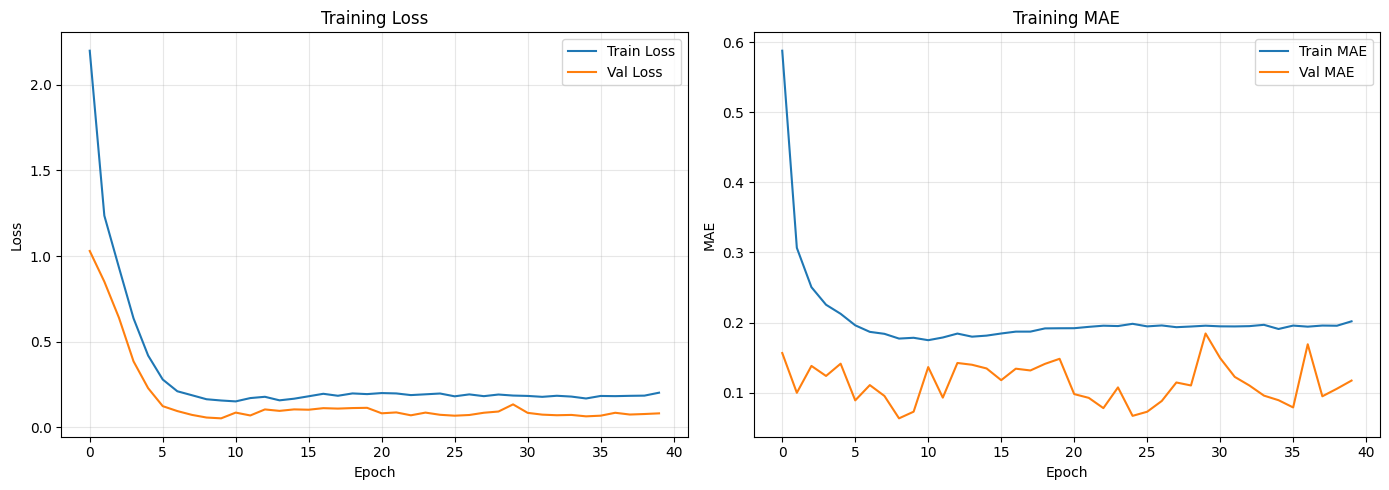

Final: train_loss=0.202213, val_loss=0.081567


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_xlabel('Epoch'), axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss'), axes[0].legend(), axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['mae'], label='Train MAE')
axes[1].plot(history.history['val_mae'], label='Val MAE')
axes[1].set_xlabel('Epoch'), axes[1].set_ylabel('MAE')
axes[1].set_title('Training MAE'), axes[1].legend(), axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final: train_loss={history.history['loss'][-1]:.6f}, val_loss={history.history['val_loss'][-1]:.6f}")

## Model Evaluation

In [27]:
start_time = time.time()
y_pred_scaled = model.predict(X_test_seq)
prediction_time = time.time() - start_time

# Inverse transform for single output
y_pred_pod_count = scaler_y.inverse_transform(y_pred_scaled).flatten()
y_test_pod_count = scaler_y.inverse_transform(y_test_seq).flatten()

print(f"Predictions: {y_pred_pod_count.shape} in {prediction_time:.4f}s ({prediction_time/len(X_test_seq)*1000:.2f} ms/sample)")

203/203 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step
Predictions: (6469,) in 2.6932s (0.42 ms/sample)


In [28]:
# Pod count prediction evaluation
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

mse = mean_squared_error(y_test_pod_count, y_pred_pod_count)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_pod_count, y_pred_pod_count)
r2 = r2_score(y_test_pod_count, y_pred_pod_count)

# Pod-specific metrics
y_pred_rounded = np.round(y_pred_pod_count).astype(int)
y_test_int = np.round(y_test_pod_count).astype(int)
exact_accuracy = np.mean(y_pred_rounded == y_test_int) * 100
within_1_accuracy = np.mean(np.abs(y_pred_rounded - y_test_int) <= 1) * 100
within_2_accuracy = np.mean(np.abs(y_pred_rounded - y_test_int) <= 2) * 100

# Under/over prediction analysis
under_predictions = np.sum(y_pred_rounded < y_test_int)
over_predictions = np.sum(y_pred_rounded > y_test_int)
exact_predictions = np.sum(y_pred_rounded == y_test_int)

print("=" * 60)
print("POD COUNT PREDICTION METRICS")
print("=" * 60)
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R²:   {r2:.4f}")
print()
print("=" * 60)
print("AUTOSCALING-SPECIFIC METRICS")
print("=" * 60)
print(f"Exact Match Accuracy: {exact_accuracy:.2f}%")
print(f"Within ±1 Pod:        {within_1_accuracy:.2f}%")
print(f"Within ±2 Pods:       {within_2_accuracy:.2f}%")
print()
print(f"Under-predictions: {under_predictions} ({under_predictions/len(y_test_int)*100:.1f}%) - RISK: SLA violations")
print(f"Over-predictions:  {over_predictions} ({over_predictions/len(y_test_int)*100:.1f}%) - COST: Resource waste")
print(f"Exact predictions: {exact_predictions} ({exact_predictions/len(y_test_int)*100:.1f}%)")

POD COUNT PREDICTION METRICS
MSE:  0.1156
RMSE: 0.3400
MAE:  0.2381
R²:   0.9802

AUTOSCALING-SPECIFIC METRICS
Exact Match Accuracy: 94.56%
Within ±1 Pod:        99.10%
Within ±2 Pods:       100.00%

Under-predictions: 47 (0.7%) - RISK: SLA violations
Over-predictions:  305 (4.7%) - COST: Resource waste
Exact predictions: 6117 (94.6%)


FINAL POD COUNT PREDICTION SUMMARY
R²:   0.9802
RMSE: 0.3400
MAE:  0.2381
Exact Match: 94.56%
Within ±1:   99.10%

Training time: 15.44 min, Inference: 0.42 ms/sample
Parameters: 78,593


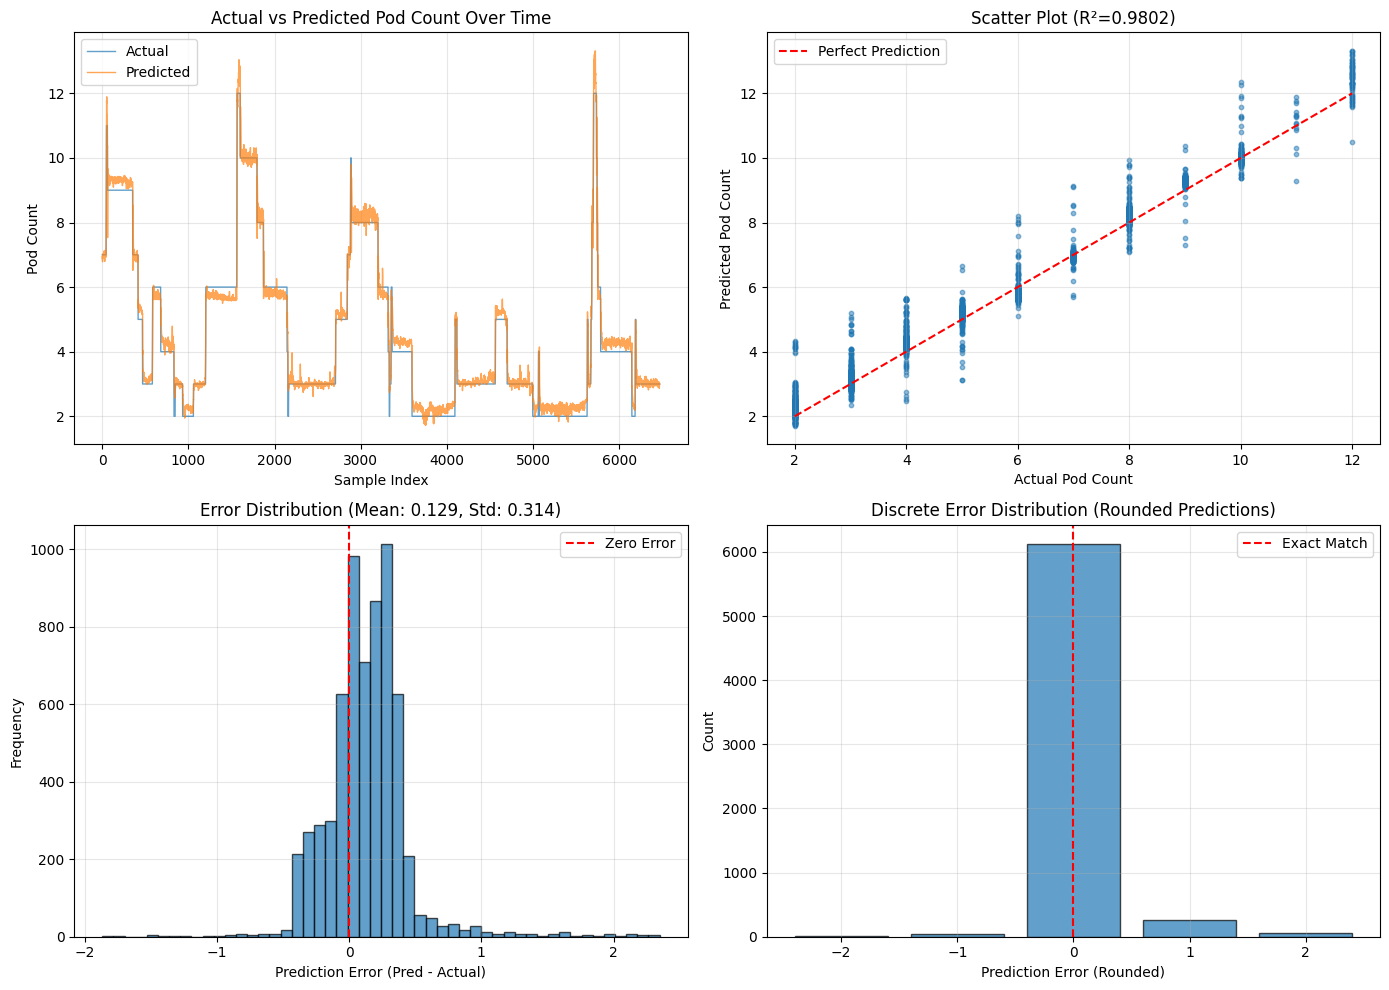

In [29]:
print("=" * 60)
print("FINAL POD COUNT PREDICTION SUMMARY")
print("=" * 60)

print(f"R²:   {r2:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"Exact Match: {exact_accuracy:.2f}%")
print(f"Within ±1:   {within_1_accuracy:.2f}%")

print(f"\nTraining time: {training_time/60:.2f} min, Inference: {prediction_time/len(X_test_seq)*1000:.2f} ms/sample")
print(f"Parameters: {model.count_params():,}")

# Visualization: Actual vs Predicted Pod Count
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Time series comparison
ax1 = axes[0, 0]
time_index = range(len(y_test_pod_count))
ax1.plot(time_index, y_test_pod_count, label='Actual', alpha=0.7, linewidth=1)
ax1.plot(time_index, y_pred_pod_count, label='Predicted', alpha=0.7, linewidth=1)
ax1.set_xlabel('Sample Index')
ax1.set_ylabel('Pod Count')
ax1.set_title('Actual vs Predicted Pod Count Over Time')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Scatter plot
ax2 = axes[0, 1]
ax2.scatter(y_test_pod_count, y_pred_pod_count, alpha=0.5, s=10)
ax2.plot([y_test_pod_count.min(), y_test_pod_count.max()],
         [y_test_pod_count.min(), y_test_pod_count.max()], 'r--', label='Perfect Prediction')
ax2.set_xlabel('Actual Pod Count')
ax2.set_ylabel('Predicted Pod Count')
ax2.set_title(f'Scatter Plot (R²={r2:.4f})')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Error distribution
ax3 = axes[1, 0]
errors = y_pred_pod_count - y_test_pod_count
ax3.hist(errors, bins=50, edgecolor='black', alpha=0.7)
ax3.axvline(x=0, color='r', linestyle='--', label='Zero Error')
ax3.set_xlabel('Prediction Error (Pred - Actual)')
ax3.set_ylabel('Frequency')
ax3.set_title(f'Error Distribution (Mean: {np.mean(errors):.3f}, Std: {np.std(errors):.3f})')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Rounded accuracy distribution
ax4 = axes[1, 1]
error_rounded = y_pred_rounded - y_test_int
unique_errors, counts = np.unique(error_rounded, return_counts=True)
ax4.bar(unique_errors, counts, edgecolor='black', alpha=0.7)
ax4.axvline(x=0, color='r', linestyle='--', label='Exact Match')
ax4.set_xlabel('Prediction Error (Rounded)')
ax4.set_ylabel('Count')
ax4.set_title('Discrete Error Distribution (Rounded Predictions)')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [30]:
import os

os.makedirs('data', exist_ok=True)

eval_df = pd.DataFrame({
    'timestamp': test_df['timestamp'].iloc[LOOKBACK:].reset_index(drop=True),
    'pod_count_actual': y_test_pod_count,
    'pod_count_predicted': y_pred_pod_count,
    'pod_count_pred_rounded': y_pred_rounded,
    'error': y_pred_pod_count - y_test_pod_count,
    'error_rounded': y_pred_rounded - y_test_int
})

csv_path = 'data/informer_pod_count_eval.csv'
eval_df.to_csv(csv_path, index=False)
print(f'Saved {len(eval_df)} rows to {csv_path}')

Saved 6469 rows to data/informer_pod_count_eval.csv


## Save Informer Model and Artifacts

In [31]:
import os
import pickle
from datetime import datetime

os.makedirs("models", exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
service_safe = str(SERVICE_NAME).lower()

model_path = f"models/informer-podcount-{service_safe}-{timestamp}.keras"
model.save(model_path)

artifacts = {
    "feature_cols": feature_cols,
    "target_cols": target_cols,  # Now ['future_current_pod_count']
    "scaler_X": scaler_X,
    "scaler_y": scaler_y,
    "lookback": LOOKBACK,
    "prediction_horizon": PREDICTION_HORIZON,
    "model_type": "pod_count_prediction",  # Semantic clarity
}

artifacts_path = f"models/informer-podcount-{service_safe}-{timestamp}-artifacts.pkl"
with open(artifacts_path, "wb") as f:
    pickle.dump(artifacts, f)

print(f"Saved Informer model to {model_path}")
print(f"Saved preprocessing artifacts to {artifacts_path}")
print(f"Target: {target_cols[0]} (single output for autoscaling)")

Saved Informer model to models/informer-podcount-order-20251211_053220.keras
Saved preprocessing artifacts to models/informer-podcount-order-20251211_053220-artifacts.pkl
Target: future_current_pod_count (single output for autoscaling)
